# ECR1-C — Mahmuda
# PanTS: The Pancreatic Tumor Segmentation — Report-I Reproduction Pilot

**Goal:** Reproduce a pancreatic tumor segmentation pipeline using a small Kaggle-accessible subset and **nnU-Net 2D**, following the PanTS reproduction guidance.

### Workflow
1. **Step-I — Reproduce for PanRS/PanTS context:** inspect the PanTS repository and document the reproduction target.
2. **Step-II — Download/use one accessible dataset:** use the Kaggle pancreatic cancer segmentation dataset already attached to this Kaggle notebook.
3. **Step-III — Apply a published model:** use **nnU-Net v2 2D** as the segmentation baseline.
4. **Pilot training:** use a small subset and only 5 epochs so the full pipeline can be completed quickly.
5. **Testing:** predict on the held-out Kaggle test subset and calculate Dice, IoU, precision, recall and HD95.
6. **Report-I outputs:** save the checkpoint, predictions/metrics, testing script, and a short README.

> **Important:** This is a reproduction pilot on an accessible Kaggle dataset, not the official 9,000-case PanTS training set or 901-case PanTS in-distribution test set. The official PanTS repository states that the full data download requires about 300 GB. 

## Step-I — Reproduce for PanTS/PanRS

The official PanTS repository describes PanTS as a large multi-institutional pancreatic CT dataset and lists **PanTS-tr (9,000)** and **PanTS-te (901)** as its official train/test sets. It also lists nnU-Net among the benchmark models.

Because the full PanTS download is very large, this notebook uses a small accessible Kaggle pancreatic tumor segmentation dataset for a reproducible pilot, as permitted by the task guidance.

**Reference:** https://github.com/MrGiovanni/PanTS

In [1]:
# Step-I: Environment and reproducibility settings
import os, sys, json, random, shutil, subprocess, textwrap, time, glob
from pathlib import Path

SEED = 42
random.seed(SEED)

print("Python:", sys.version)
print("Working directory:", os.getcwd())
print("Kaggle input:", os.listdir("/kaggle/input")[:20])

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Working directory: /kaggle/working
Kaggle input: ['datasets']


## Step-II — Select the accessible Kaggle dataset

The notebook expects the Kaggle dataset used in the pilot to contain:

- `Dataset/Dataset/X_train`
- `Dataset/Dataset/X_test`
- `Mask/Mask/Y_train_Cancer`
- `Mask/Mask/Y_test_Cancer`

The cancer masks use the `_modified.png` suffix.

The pilot intentionally uses only a small number of cases to reduce runtime.

In [2]:
# Locate the Kaggle dataset automatically
INPUT_ROOT = Path("/kaggle/input")

candidate_sources = [
    INPUT_ROOT / "datasets/piyansusaha/pancreas-cancer-segmentetion",
]

SOURCE = None
for p in candidate_sources:
    if p.exists():
        SOURCE = p
        break

if SOURCE is None:
    # Fallback: search for the expected folder structure
    for p in INPUT_ROOT.rglob("X_train"):
        if (p / "11396.png").exists() or (p.parent.parent / "Mask").exists():
            SOURCE = p.parent.parent
            break

if SOURCE is None:
    raise FileNotFoundError(
        "Could not locate the Kaggle pancreatic dataset. "
        "Check the Kaggle input dataset path."
    )

DATASET_DIR = SOURCE / "Dataset" / "Dataset"
MASK_DIR = SOURCE / "Mask" / "Mask"

print("SOURCE:", SOURCE)
print("DATASET_DIR:", DATASET_DIR)
print("MASK_DIR:", MASK_DIR)

for p in [
    DATASET_DIR / "X_train",
    DATASET_DIR / "X_test",
    MASK_DIR / "Y_train_Cancer",
    MASK_DIR / "Y_test_Cancer",
]:
    print(p, "->", p.exists())

SOURCE: /kaggle/input/datasets/piyansusaha/pancreas-cancer-segmentetion
DATASET_DIR: /kaggle/input/datasets/piyansusaha/pancreas-cancer-segmentetion/Dataset/Dataset
MASK_DIR: /kaggle/input/datasets/piyansusaha/pancreas-cancer-segmentetion/Mask/Mask
/kaggle/input/datasets/piyansusaha/pancreas-cancer-segmentetion/Dataset/Dataset/X_train -> True
/kaggle/input/datasets/piyansusaha/pancreas-cancer-segmentetion/Dataset/Dataset/X_test -> True
/kaggle/input/datasets/piyansusaha/pancreas-cancer-segmentetion/Mask/Mask/Y_train_Cancer -> True
/kaggle/input/datasets/piyansusaha/pancreas-cancer-segmentetion/Mask/Mask/Y_test_Cancer -> True


Available train images: 9035
Available test images: 1835
Sample: 1000.png
Image shape: (512, 512)
Mask shape: (512, 512)
Mask values: [  0 255]


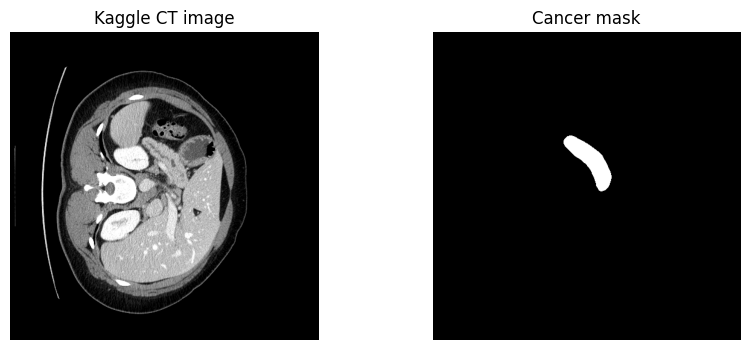

In [3]:
# Inspect dataset size and one example
import cv2
import numpy as np
import matplotlib.pyplot as plt

train_all = sorted([x for x in os.listdir(DATASET_DIR / "X_train") if x.lower().endswith(".png")])
test_all = sorted([x for x in os.listdir(DATASET_DIR / "X_test") if x.lower().endswith(".png")])

print("Available train images:", len(train_all))
print("Available test images:", len(test_all))

sample_name = train_all[0]
img = cv2.imread(str(DATASET_DIR / "X_train" / sample_name), cv2.IMREAD_GRAYSCALE)
mask_name = sample_name.replace(".png", "_modified.png")
mask = cv2.imread(str(MASK_DIR / "Y_train_Cancer" / mask_name), cv2.IMREAD_GRAYSCALE)

print("Sample:", sample_name)
print("Image shape:", img.shape)
print("Mask shape:", mask.shape)
print("Mask values:", np.unique(mask))

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(img, cmap="gray")
plt.title("Kaggle CT image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Cancer mask")
plt.axis("off")
plt.show()

## Pilot configuration

For a quick end-to-end reproduction:

- **Training cases:** up to 300
- **External test cases:** up to 50
- **Model:** nnU-Net v2, 2D configuration
- **Training:** 5 epochs
- **GPU:** one GPU by default
- **Seed:** 42

If fewer cases are available, the notebook automatically uses all available cases.

In [4]:
# Pilot controls — change only these if needed
PILOT_TRAIN_CASES = 300
PILOT_TEST_CASES = 50
PILOT_EPOCHS = 5

# Use one GPU for the quick pilot. Change to 2 only if you intentionally want multi-GPU.
NUM_GPUS = 1

# Keep only images for which the cancer mask exists
def has_mask(base_dir, mask_dir, name):
    m = mask_dir / name.replace(".png", "_modified.png")
    return m.exists()

train_available = [x for x in train_all if has_mask(DATASET_DIR/"X_train", MASK_DIR/"Y_train_Cancer", x)]
test_available = [x for x in test_all if has_mask(DATASET_DIR/"X_test", MASK_DIR/"Y_test_Cancer", x)]

# Deterministic subset
rng = random.Random(SEED)
rng.shuffle(train_available)
rng.shuffle(test_available)

PILOT_TRAIN = sorted(train_available[:min(PILOT_TRAIN_CASES, len(train_available))])
PILOT_TEST = sorted(test_available[:min(PILOT_TEST_CASES, len(test_available))])

print("Pilot train cases:", len(PILOT_TRAIN))
print("Pilot test cases:", len(PILOT_TEST))
print("First train cases:", PILOT_TRAIN[:5])
print("First test cases:", PILOT_TEST[:5])

Pilot train cases: 300
Pilot test cases: 50
First train cases: ['1001.png', '10142.png', '10149.png', '10179.png', '10367.png']
First test cases: ['1050.png', '1081.png', '1301.png', '1304.png', '1501.png']


## Step-II-A — Install nnU-Net v2

In [5]:
# Install nnU-Net v2
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "nnunetv2"], check=True)

import torch
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(i, torch.cuda.get_device_name(i))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.1/291.1 kB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.8/102.8 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.8/76.8 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.6/53.6 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.1/28.1 MB 70.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 86.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 96.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 67.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.4/96.4 kB 8.3 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
ydata-profiling 4.18.4 requires numpy<2.4,>=1.22, but you have numpy 2.5.3 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.5.3 which is incompatible.


PyTorch: 2.10.0+cu128
CUDA available: True
GPU count: 2
0 Tesla T4
1 Tesla T4


## Step-II-B — Create the nnU-Net dataset

nnU-Net expects NIfTI files and a `dataset.json`. The 2D PNG images are therefore converted to 2D NIfTI images, and the binary tumor masks are converted to labels:

- `0` = background
- `1` = pancreatic tumor

In [7]:
# nnU-Net directories
os.environ["nnUNet_raw"] = "/kaggle/working/nnUNet_raw"
os.environ["nnUNet_preprocessed"] = "/kaggle/working/nnUNet_preprocessed"
os.environ["nnUNet_results"] = "/kaggle/working/nnUNet_results"

for k in ["nnUNet_raw", "nnUNet_preprocessed", "nnUNet_results"]:
    Path(os.environ[k]).mkdir(parents=True, exist_ok=True)

DATASET_ID = 1
NNUNET_NAME = "PancreaticTumorPilot"
OUT_DIR = Path(os.environ["nnUNet_raw"]) / f"Dataset{DATASET_ID:03d}_{NNUNET_NAME}"

IMAGES_TR = OUT_DIR / "imagesTr"
LABELS_TR = OUT_DIR / "labelsTr"
IMAGES_TS = OUT_DIR / "imagesTs"

for p in [IMAGES_TR, LABELS_TR, IMAGES_TS]:
    p.mkdir(parents=True, exist_ok=True)

print("nnU-Net dataset:", OUT_DIR)

nnU-Net dataset: /kaggle/working/nnUNet_raw/Dataset001_PancreaticTumorPilot


In [8]:
# Convert PNG -> 2D NIfTI
import nibabel as nib
from tqdm.auto import tqdm

def png_to_nii(src, dst, is_label=False):
    arr = cv2.imread(str(src), cv2.IMREAD_GRAYSCALE)
    if arr is None:
        raise ValueError(f"Cannot read {src}")
    if is_label:
        arr = (arr > 0).astype(np.uint8)
    else:
        arr = arr.astype(np.float32)
    nii = nib.Nifti1Image(arr, np.eye(4))
    nib.save(nii, str(dst))

# Training
for name in tqdm(PILOT_TRAIN, desc="Converting train"):
    png_to_nii(
        DATASET_DIR / "X_train" / name,
        IMAGES_TR / name.replace(".png", "_0000.nii.gz"),
        is_label=False,
    )
    png_to_nii(
        MASK_DIR / "Y_train_Cancer" / name.replace(".png", "_modified.png"),
        LABELS_TR / name.replace(".png", ".nii.gz"),
        is_label=True,
    )

# Test images
for name in tqdm(PILOT_TEST, desc="Converting test"):
    png_to_nii(
        DATASET_DIR / "X_test" / name,
        IMAGES_TS / name.replace(".png", "_0000.nii.gz"),
        is_label=False,
    )

print("Converted:", len(list(IMAGES_TR.glob("*.nii.gz"))), "train images")
print("Converted:", len(list(LABELS_TR.glob("*.nii.gz"))), "train labels")
print("Converted:", len(list(IMAGES_TS.glob("*.nii.gz"))), "test images")

Converting train:   0%|          | 0/300 [00:00<?, ?it/s]

Converting test:   0%|          | 0/50 [00:00<?, ?it/s]

Converted: 300 train images
Converted: 300 train labels
Converted: 50 test images


In [9]:
# Create dataset.json
dataset_json = {
    "channel_names": {"0": "CT"},
    "labels": {"background": 0, "tumor": 1},
    "numTraining": len(PILOT_TRAIN),
    "file_ending": ".nii.gz"
}

with open(OUT_DIR / "dataset.json", "w") as f:
    json.dump(dataset_json, f, indent=2)

print(json.dumps(dataset_json, indent=2))

{
  "channel_names": {
    "0": "CT"
  },
  "labels": {
    "background": 0,
    "tumor": 1
  },
  "numTraining": 300,
  "file_ending": ".nii.gz"
}


## Step-II-C — Verify the nnU-Net dataset

In [10]:
# Dataset integrity check
env = os.environ.copy()

cmd = [
    "nnUNetv2_plan_and_preprocess",
    "-d", str(DATASET_ID),
    "--verify_dataset_integrity"
]

result = subprocess.run(cmd, env=env, text=True, capture_output=True)
print(result.stdout)
if result.stderr:
    print(result.stderr)

if result.returncode != 0:
    raise RuntimeError("nnU-Net dataset verification failed.")

Fingerprint extraction...
Dataset001_PancreaticTumorPilot
Using <class 'nnunetv2.imageio.simpleitk_reader_writer.SimpleITKIO'> as reader/writer

####################
verify_dataset_integrity Done. 
If you didn't see any error messages then your dataset is most likely OK!
####################

Using <class 'nnunetv2.imageio.simpleitk_reader_writer.SimpleITKIO'> as reader/writer
Experiment planning...

############################
INFO: You are using the old nnU-Net default planner. We have updated our recommendations. Please consider using those instead! Read more here: https://github.com/MIC-DKFZ/nnUNet/blob/master/documentation/resenc_presets.md
############################

2D U-Net configuration:
{'data_identifier': 'nnUNetPlans_2d', 'preprocessor_name': 'DefaultPreprocessor', 'batch_size': 13, 'patch_size': (np.int64(448), np.int64(448)), 'median_image_size_in_voxels': array([392. , 446.5]), 'spacing': array([1., 1.]), 'normalization_schemes': ['CTNormalization'], 'use_mask_for_nor

## Step-III — Apply nnU-Net (5-epoch pilot)

nnU-Net is used as the reproduced baseline model. The official nnU-Net workflow automatically fingerprints the dataset, creates a suitable configuration, preprocesses the data, trains the network and supports inference.

For this **pilot**, training is intentionally shortened to 5 epochs. This is not intended to reproduce a publication-quality final score; it is intended to prove that the full reproduction pipeline works end-to-end.

In [11]:
# Plan and preprocess
result = subprocess.run(
    ["nnUNetv2_plan_and_preprocess", "-d", str(DATASET_ID)],
    env=env, text=True, capture_output=True
)
print(result.stdout[-12000:])
if result.stderr:
    print("\nSTDERR:\n", result.stderr[-5000:])
if result.returncode != 0:
    raise RuntimeError("nnU-Net planning/preprocessing failed.")

Fingerprint extraction...
Dataset001_PancreaticTumorPilot
Experiment planning...

############################
INFO: You are using the old nnU-Net default planner. We have updated our recommendations. Please consider using those instead! Read more here: https://github.com/MIC-DKFZ/nnUNet/blob/master/documentation/resenc_presets.md
############################

2D U-Net configuration:
{'data_identifier': 'nnUNetPlans_2d', 'preprocessor_name': 'DefaultPreprocessor', 'batch_size': 13, 'patch_size': (np.int64(448), np.int64(448)), 'median_image_size_in_voxels': array([392. , 446.5]), 'spacing': array([1., 1.]), 'normalization_schemes': ['CTNormalization'], 'use_mask_for_norm': [False], 'resampling_fn_data': 'resample_data_or_seg_to_shape', 'resampling_fn_seg': 'resample_data_or_seg_to_shape', 'resampling_fn_data_kwargs': {'is_seg': False, 'order': 3, 'order_z': 0, 'force_separate_z': None}, 'resampling_fn_seg_kwargs': {'is_seg': True, 'order': 1, 'order_z': 0, 'force_separate_z': None}, 'r

## Step-III-A — Create a 5-epoch nnU-Net trainer

The standard nnU-Net trainer is designed for full training. This pilot subclass changes only the number of epochs to 5 so that the complete pipeline can be tested quickly.

In [12]:
import nnunetv2

trainer_dir = Path("/kaggle/working/pilot_trainer")
trainer_dir.mkdir(exist_ok=True)

trainer_file = trainer_dir / "nnUNetTrainer_Pilot5.py"

trainer_code = f'''
from nnunetv2.training.nnUNetTrainer.nnUNetTrainer import nnUNetTrainer

class nnUNetTrainer_Pilot5(nnUNetTrainer):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.num_epochs = {PILOT_EPOCHS}
'''

trainer_file.write_text(trainer_code)

# Also write a copy directly inside the installed nnunetv2 trainer package,
# since nnUNetv2_train scans that package folder for trainer classes.
nnunet_trainer_dir = Path(nnunetv2.__file__).parent / "training" / "nnUNetTrainer"
installed_trainer_file = nnunet_trainer_dir / "nnUNetTrainer_Pilot5.py"
installed_trainer_file.write_text(trainer_code)

print(trainer_file.read_text())
print("Installed copy at:", installed_trainer_file)


from nnunetv2.training.nnUNetTrainer.nnUNetTrainer import nnUNetTrainer

class nnUNetTrainer_Pilot5(nnUNetTrainer):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.num_epochs = 5

Installed copy at: /usr/local/lib/python3.12/dist-packages/nnunetv2/training/nnUNetTrainer/nnUNetTrainer_Pilot5.py


## Step-III-B — Train the pilot model

In [13]:
# Train nnU-Net pilot
# One GPU keeps the pilot simple and avoids DDP overhead.
# Use nnU-Net's built-in 5-epoch trainer variant instead of a custom one,
# since custom __init__ signatures can break across nnunetv2 versions.
train_cmd = [
    "nnUNetv2_train",
    str(DATASET_ID),
    "2d",
    "0",
    "-tr", "nnUNetTrainer_5epochs",
    "-num_gpus", str(NUM_GPUS)
]

print("Running:", " ".join(train_cmd))

result = subprocess.run(
    train_cmd,
    env=env,
    text=True,
    cwd="/kaggle/working",
)

if result.returncode != 0:
    raise RuntimeError("Pilot training failed.")

print("Pilot training completed.")

Running: nnUNetv2_train 1 2d 0 -tr nnUNetTrainer_5epochs -num_gpus 1

############################
INFO: You are using the old nnU-Net default plans. We have updated our recommendations. Please consider using those instead! Read more here: https://github.com/MIC-DKFZ/nnUNet/blob/master/documentation/resenc_presets.md
############################

Using device: cuda:0

#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

2026-09-14 06:36:29.217387: Using torch.compile...
2026-09-14 06:36:31.589956: do_dummy_2d_data_aug: False
2026-09-14 06:36:31.590982: Creating new 5-fold cross-validation split...
2026-09-14 06:36:31.594375: Desired fold for t

W0914 06:36:49.980000 20127 torch/_inductor/utils.py:1679] [0/0] Not enough SMs to use max_autotune_gemm mode
/usr/local/lib/python3.12/dist-packages/torch/_inductor/lowering.py:7627: UserWarning: 
Online softmax is disabled on the fly since Inductor decides to
split the reduction. Cut an issue to PyTorch if this is an
important use case and you want to speed it up with online
softmax.

  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/_inductor/lowering.py:7627: UserWarning: 
Online softmax is disabled on the fly since Inductor decides to
split the reduction. Cut an issue to PyTorch if this is an
important use case and you want to speed it up with online
softmax.

  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/_inductor/lowering.py:7627: UserWarning: 
Online softmax is disabled on the fly since Inductor decides to
split the reduction. Cut an issue to PyTorch if this is an
important use case and you want to speed it up with online
softmax.

  warnings.warn(

using pin_memory on device 0

This is the configuration used by this training:
Configuration name: 2d
 {'data_identifier': 'nnUNetPlans_2d', 'preprocessor_name': 'DefaultPreprocessor', 'batch_size': 13, 'patch_size': [448, 448], 'median_image_size_in_voxels': [392.0, 446.5], 'spacing': [1.0, 1.0], 'normalization_schemes': ['CTNormalization'], 'use_mask_for_norm': [False], 'resampling_fn_data': 'resample_data_or_seg_to_shape', 'resampling_fn_seg': 'resample_data_or_seg_to_shape', 'resampling_fn_data_kwargs': {'is_seg': False, 'order': 3, 'order_z': 0, 'force_separate_z': None}, 'resampling_fn_seg_kwargs': {'is_seg': True, 'order': 1, 'order_z': 0, 'force_separate_z': None}, 'resampling_fn_probabilities': 'resample_data_or_seg_to_shape', 'resampling_fn_probabilities_kwargs': {'is_seg': False, 'order': 1, 'order_z': 0, 'force_separate_z': None}, 'architecture': {'network_class_name': 'dynamic_network_architectures.architectures.unet.PlainConvUNet', 'arch_kwargs': {'n_stages': 7, 'features

## Step-III-C — Locate the best checkpoint

In [14]:
# Locate checkpoints
result_root = Path(os.environ["nnUNet_results"])
checkpoints = sorted(result_root.rglob("checkpoint_best.pth"))

print("Best checkpoints found:")
for p in checkpoints:
    print(p)

if not checkpoints:
    # Fall back to any checkpoint if best is unavailable
    checkpoints = sorted(result_root.rglob("checkpoint_final.pth"))

if not checkpoints:
    raise FileNotFoundError("No nnU-Net checkpoint was found.")

BEST_CHECKPOINT = checkpoints[0]
print("\nUsing:", BEST_CHECKPOINT)

Best checkpoints found:
/kaggle/working/nnUNet_results/Dataset001_PancreaticTumorPilot/nnUNetTrainer_5epochs__nnUNetPlans__2d/fold_0/checkpoint_best.pth

Using: /kaggle/working/nnUNet_results/Dataset001_PancreaticTumorPilot/nnUNetTrainer_5epochs__nnUNetPlans__2d/fold_0/checkpoint_best.pth


## Testing — Run inference on the held-out Kaggle test subset

In [15]:
# Predict test images
PRED_DIR = Path("/kaggle/working/predictions")
PRED_DIR.mkdir(exist_ok=True)

predict_cmd = [
    "nnUNetv2_predict",
    "-i", str(IMAGES_TS),
    "-o", str(PRED_DIR),
    "-d", str(DATASET_ID),
    "-c", "2d",
    "-f", "0",
    "-tr", "nnUNetTrainer_5epochs",
    "-chk", str(BEST_CHECKPOINT),
    "--disable_tta"
]

print("Running:", " ".join(predict_cmd))

result = subprocess.run(
    predict_cmd,
    env=env,
    text=True,
    capture_output=True
)
print(result.stdout[-12000:])
if result.stderr:
    print("\nSTDERR:\n", result.stderr[-5000:])

if result.returncode != 0:
    raise RuntimeError("Inference failed.")

print("Prediction files:", len(list(PRED_DIR.glob("*.nii.gz"))))

Running: nnUNetv2_predict -i /kaggle/working/nnUNet_raw/Dataset001_PancreaticTumorPilot/imagesTs -o /kaggle/working/predictions -d 1 -c 2d -f 0 -tr nnUNetTrainer_5epochs -chk /kaggle/working/nnUNet_results/Dataset001_PancreaticTumorPilot/nnUNetTrainer_5epochs__nnUNetPlans__2d/fold_0/checkpoint_best.pth --disable_tta

#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

There are 50 cases in the source folder
I am process 0 out of 1 (max process ID is 0, we start counting with 0!)
There are 50 cases that I would like to predict

Predicting 1050:
perform_everything_on_device: True
sending off prediction to background worker for resampling and ex

## Testing — Quantitative segmentation metrics

The following metrics are calculated against the original Kaggle cancer masks:

- **Dice**
- **IoU**
- **Precision**
- **Recall**
- **HD95** (when both masks contain foreground)

The test evaluation is on the small pilot test subset, not the official PanTS-te benchmark.

In [16]:
import pandas as pd

def dice_score(gt, pred):
    gt = gt.astype(bool)
    pred = pred.astype(bool)
    inter = np.logical_and(gt, pred).sum()
    denom = gt.sum() + pred.sum()
    if denom == 0:
        return 1.0
    return 2.0 * inter / denom

def iou_score(gt, pred):
    gt = gt.astype(bool)
    pred = pred.astype(bool)
    inter = np.logical_and(gt, pred).sum()
    union = np.logical_or(gt, pred).sum()
    if union == 0:
        return 1.0
    return inter / union

def precision_score(gt, pred):
    gt = gt.astype(bool)
    pred = pred.astype(bool)
    tp = np.logical_and(gt, pred).sum()
    fp = np.logical_and(~gt, pred).sum()
    return tp / (tp + fp + 1e-8)

def recall_score(gt, pred):
    gt = gt.astype(bool)
    pred = pred.astype(bool)
    tp = np.logical_and(gt, pred).sum()
    fn = np.logical_and(gt, ~pred).sum()
    return tp / (tp + fn + 1e-8)

# Distance transform and surface extraction via OpenCV instead of scipy.ndimage,
# to avoid the numpy/scipy binary version mismatch caused by the nnunetv2 install.
def edt_from_mask(mask):
    # Distance from every pixel to the nearest True pixel in `mask`.
    src = np.where(mask, 0, 255).astype(np.uint8)
    return cv2.distanceTransform(src, cv2.DIST_L2, 5)

def get_surface(mask):
    m = mask.astype(np.uint8)
    kernel = np.ones((3, 3), np.uint8)
    eroded = cv2.erode(m, kernel, iterations=1)
    return m.astype(bool) ^ eroded.astype(bool)

def hd95(gt, pred):
    gt = gt.astype(bool)
    pred = pred.astype(bool)
    if not gt.any() and not pred.any():
        return 0.0
    if not gt.any() or not pred.any():
        return np.nan

    gt_s = get_surface(gt)
    pred_s = get_surface(pred)

    dt_gt = edt_from_mask(gt)
    dt_pred = edt_from_mask(pred)

    d1 = dt_pred[gt_s]
    d2 = dt_gt[pred_s]
    return float(np.percentile(np.concatenate([d1, d2]), 95))

rows = []

for name in tqdm(PILOT_TEST, desc="Evaluating"):
    stem = name.replace(".png", "")
    pred_path = PRED_DIR / f"{stem}.nii.gz"
    gt_path = MASK_DIR / "Y_test_Cancer" / name.replace(".png", "_modified.png")

    if not pred_path.exists():
        print("Missing prediction:", pred_path)
        continue

    pred = np.asarray(nib.load(str(pred_path)).get_fdata()) > 0
    gt = cv2.imread(str(gt_path), cv2.IMREAD_GRAYSCALE) > 0

    if pred.shape != gt.shape:
        raise ValueError(f"Shape mismatch for {name}: pred={pred.shape}, gt={gt.shape}")

    rows.append({
        "case": name,
        "dice": dice_score(gt, pred),
        "iou": iou_score(gt, pred),
        "precision": precision_score(gt, pred),
        "recall": recall_score(gt, pred),
        "hd95": hd95(gt, pred),
        "gt_positive": bool(gt.any()),
        "pred_positive": bool(pred.any()),
    })

metrics_df = pd.DataFrame(rows)

print(metrics_df.head())

summary = metrics_df[["dice", "iou", "precision", "recall", "hd95"]].mean(numeric_only=True)
print("\n===== PILOT TEST RESULTS =====")
print(summary)

metrics_df.to_csv("/kaggle/working/pilot_test_metrics.csv", index=False)
summary.to_frame("mean").to_csv("/kaggle/working/pilot_summary_metrics.csv")

print("\nSaved:")
print("/kaggle/working/pilot_test_metrics.csv")
print("/kaggle/working/pilot_summary_metrics.csv")

Evaluating:   0%|          | 0/50 [00:00<?, ?it/s]

       case      dice       iou  precision    recall       hd95  gt_positive  \
0  1050.png  1.000000  1.000000   0.000000  0.000000   0.000000        False   
1  1081.png  0.000000  0.000000   0.000000  0.000000        NaN        False   
2  1301.png  0.537118  0.367164   0.566820  0.510373  14.399994         True   
3  1304.png  0.000000  0.000000   0.000000  0.000000        NaN         True   
4  1501.png  0.357983  0.218014   0.306299  0.430651  40.624420         True   

   pred_positive  
0          False  
1           True  
2           True  
3          False  
4           True  

===== PILOT TEST RESULTS =====
dice          0.440758
iou           0.371826
precision     0.217933
recall        0.339543
hd95         32.863345
dtype: float64

Saved:
/kaggle/working/pilot_test_metrics.csv
/kaggle/working/pilot_summary_metrics.csv


## Testing — Visualize predictions

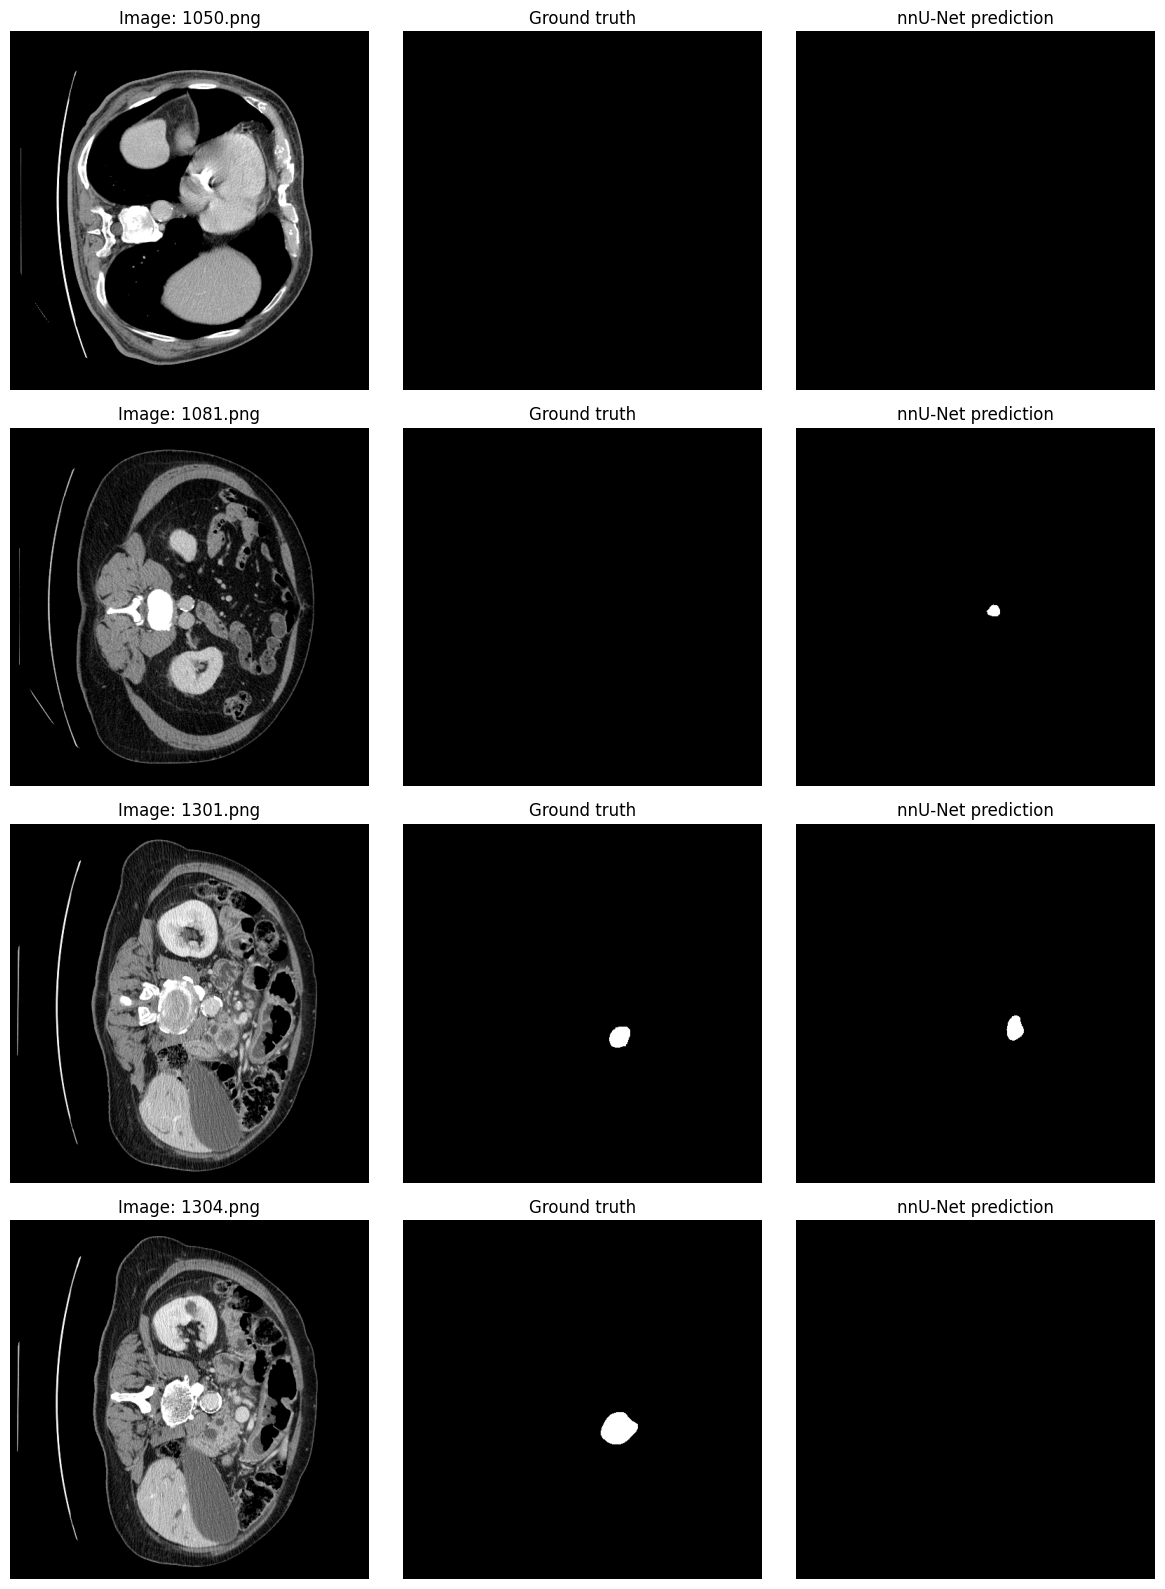

In [17]:
# Show a few prediction examples
show_n = min(4, len(PILOT_TEST))
fig, axes = plt.subplots(show_n, 3, figsize=(12, 4 * show_n))
if show_n == 1:
    axes = np.expand_dims(axes, 0)

for r, name in enumerate(PILOT_TEST[:show_n]):
    img = cv2.imread(str(DATASET_DIR / "X_test" / name), cv2.IMREAD_GRAYSCALE)
    gt = cv2.imread(
        str(MASK_DIR / "Y_test_Cancer" / name.replace(".png", "_modified.png")),
        cv2.IMREAD_GRAYSCALE
    ) > 0
    pred = np.asarray(
        nib.load(str(PRED_DIR / name.replace(".png", ".nii.gz"))).get_fdata()
    ) > 0

    axes[r,0].imshow(img, cmap="gray")
    axes[r,0].set_title(f"Image: {name}")
    axes[r,0].axis("off")

    axes[r,1].imshow(gt, cmap="gray")
    axes[r,1].set_title("Ground truth")
    axes[r,1].axis("off")

    axes[r,2].imshow(pred, cmap="gray")
    axes[r,2].set_title("nnU-Net prediction")
    axes[r,2].axis("off")

plt.tight_layout()
plt.show()

## Report-I — Save the testing script

The PanTS instructions request a testing script. This cell creates a standalone `test.py` that evaluates the saved predictions against the Kaggle test masks.

In [20]:
testing_script = '''
import os, argparse
from pathlib import Path
import cv2, nibabel as nib
import numpy as np
import pandas as pd

def dice(gt, pred):
    gt, pred = gt.astype(bool), pred.astype(bool)
    d = gt.sum() + pred.sum()
    return 1.0 if d == 0 else 2*np.logical_and(gt,pred).sum()/d

def iou(gt, pred):
    gt, pred = gt.astype(bool), pred.astype(bool)
    u = np.logical_or(gt,pred).sum()
    return 1.0 if u == 0 else np.logical_and(gt,pred).sum()/u

def edt_from_mask(mask):
    src = np.where(mask, 0, 255).astype(np.uint8)
    return cv2.distanceTransform(src, cv2.DIST_L2, 5)

def get_surface(mask):
    m = mask.astype(np.uint8)
    kernel = np.ones((3, 3), np.uint8)
    eroded = cv2.erode(m, kernel, iterations=1)
    return m.astype(bool) ^ eroded.astype(bool)

def hd95(gt, pred):
    gt, pred = gt.astype(bool), pred.astype(bool)
    if not gt.any() and not pred.any(): return 0.0
    if not gt.any() or not pred.any(): return np.nan
    gs = get_surface(gt)
    ps = get_surface(pred)
    d1 = edt_from_mask(pred)[gs]
    d2 = edt_from_mask(gt)[ps]
    return float(np.percentile(np.concatenate([d1,d2]),95))

ap = argparse.ArgumentParser()
ap.add_argument("--images", required=True)
ap.add_argument("--masks", required=True)
ap.add_argument("--predictions", required=True)
ap.add_argument("--output", default="test_metrics.csv")
args = ap.parse_args()

rows=[]
for img_name in sorted(os.listdir(args.images)):
    if not img_name.endswith(".png"): continue
    mask_name = img_name.replace(".png","_modified.png")
    pred_name = img_name.replace(".png",".nii.gz")
    gt = cv2.imread(str(Path(args.masks)/mask_name), cv2.IMREAD_GRAYSCALE) > 0
    pred = np.asarray(nib.load(str(Path(args.predictions)/pred_name)).get_fdata()) > 0
    rows.append({
        "case": img_name,
        "dice": dice(gt,pred),
        "iou": iou(gt,pred),
        "hd95": hd95(gt,pred)
    })

df=pd.DataFrame(rows)
df.to_csv(args.output,index=False)
print(df)
print("\\nMean metrics:")
print(df[["dice","iou","hd95"]].mean())
'''

TEST_SCRIPT_PATH = Path("/kaggle/working/test.py")
TEST_SCRIPT_PATH.write_text(testing_script)
print(TEST_SCRIPT_PATH.read_text())


import os, argparse
from pathlib import Path
import cv2, nibabel as nib
import numpy as np
import pandas as pd

def dice(gt, pred):
    gt, pred = gt.astype(bool), pred.astype(bool)
    d = gt.sum() + pred.sum()
    return 1.0 if d == 0 else 2*np.logical_and(gt,pred).sum()/d

def iou(gt, pred):
    gt, pred = gt.astype(bool), pred.astype(bool)
    u = np.logical_or(gt,pred).sum()
    return 1.0 if u == 0 else np.logical_and(gt,pred).sum()/u

def edt_from_mask(mask):
    src = np.where(mask, 0, 255).astype(np.uint8)
    return cv2.distanceTransform(src, cv2.DIST_L2, 5)

def get_surface(mask):
    m = mask.astype(np.uint8)
    kernel = np.ones((3, 3), np.uint8)
    eroded = cv2.erode(m, kernel, iterations=1)
    return m.astype(bool) ^ eroded.astype(bool)

def hd95(gt, pred):
    gt, pred = gt.astype(bool), pred.astype(bool)
    if not gt.any() and not pred.any(): return 0.0
    if not gt.any() or not pred.any(): return np.nan
    gs = get_surface(gt)
    ps = get_surface(pred)
    d1 =

## Report-I — Create a brief README

This README records exactly what was reproduced, what data were used, how the pilot was trained/tested, and the limitation that the official PanTS dataset was not downloaded.

In [21]:
# Create README
readme = f'''# ECR1-C — Mahmuda — Pancreatic Tumor Segmentation Reproduction Pilot

## Task
Reproduction of a pancreatic tumor segmentation pipeline following the PanTS reproduction guidance.

## Dataset
Accessible Kaggle pancreatic cancer segmentation dataset.

Pilot subset:
- Training cases: {len(PILOT_TRAIN)}
- Test cases: {len(PILOT_TEST)}
- Seed: {SEED}

This is a small pilot and is **not** the official PanTS-tr/PanTS-te benchmark.

## Model
nnU-Net v2, 2D configuration.

## Training
- Epochs: {PILOT_EPOCHS}
- Fold: 0
- GPUs: {NUM_GPUS}
- Checkpoint: {BEST_CHECKPOINT}

## Testing metrics
Dice, IoU, precision, recall and HD95.

## Output files
- `checkpoint_best.pth` — trained pilot checkpoint
- `test.py` — testing/evaluation script
- `pilot_test_metrics.csv` — per-case metrics
- `pilot_summary_metrics.csv` — mean metrics
- `predictions/` — test predictions

## Official PanTS reference
https://github.com/MrGiovanni/PanTS

The official repository describes PanTS-tr (9,000 cases), PanTS-te (901 cases), and a full data download requiring about 300 GB. This pilot uses a smaller accessible dataset because the full dataset is not practical for this reproduction run.
'''

README_PATH = Path("/kaggle/working/README.md")
README_PATH.write_text(readme)
print(readme)

# ECR1-C — Mahmuda — Pancreatic Tumor Segmentation Reproduction Pilot

## Task
Reproduction of a pancreatic tumor segmentation pipeline following the PanTS reproduction guidance.

## Dataset
Accessible Kaggle pancreatic cancer segmentation dataset.

Pilot subset:
- Training cases: 300
- Test cases: 50
- Seed: 42

This is a small pilot and is **not** the official PanTS-tr/PanTS-te benchmark.

## Model
nnU-Net v2, 2D configuration.

## Training
- Epochs: 5
- Fold: 0
- GPUs: 1
- Checkpoint: /kaggle/working/nnUNet_results/Dataset001_PancreaticTumorPilot/nnUNetTrainer_5epochs__nnUNetPlans__2d/fold_0/checkpoint_best.pth

## Testing metrics
Dice, IoU, precision, recall and HD95.

## Output files
- `checkpoint_best.pth` — trained pilot checkpoint
- `test.py` — testing/evaluation script
- `pilot_test_metrics.csv` — per-case metrics
- `pilot_summary_metrics.csv` — mean metrics
- `predictions/` — test predictions

## Official PanTS reference
https://github.com/MrGiovanni/PanTS

The official repos

## Final Report-I checklist

At the end of this notebook you should have:

- [x] Dataset inspection
- [x] Small pilot subset
- [x] PNG → NIfTI conversion
- [x] nnU-Net dataset creation
- [x] Dataset integrity verification
- [x] nnU-Net planning/preprocessing
- [x] 5-epoch pilot training
- [x] Best checkpoint
- [x] Test predictions
- [x] Dice / IoU / Precision / Recall / HD95
- [x] Visualization
- [x] Standalone testing script
- [x] Brief README

### Files to upload to the shared GitHub repository

1. `checkpoint_best.pth`
2. `test.py`
3. `pilot_test_metrics.csv`
4. `pilot_summary_metrics.csv`
5. `README.md`


In [22]:
import shutil
from pathlib import Path
from IPython.display import FileLink, display

# Collect only the Report-I deliverables into one folder
SUBMISSION_DIR = Path("/kaggle/working/Report-I_Submission")
SUBMISSION_DIR.mkdir(exist_ok=True)

deliverables = {
    "checkpoint_best.pth": BEST_CHECKPOINT,
    "test.py": Path("/kaggle/working/test.py"),
    "README.md": Path("/kaggle/working/README.md"),
    "pilot_test_metrics.csv": Path("/kaggle/working/pilot_test_metrics.csv"),
    "pilot_summary_metrics.csv": Path("/kaggle/working/pilot_summary_metrics.csv"),
}

for dest_name, src_path in deliverables.items():
    src_path = Path(src_path)
    if src_path.exists():
        shutil.copy(src_path, SUBMISSION_DIR / dest_name)
        print("Copied:", dest_name)
    else:
        print("MISSING (check earlier cells):", src_path)

# Zip the submission folder
zip_path = shutil.make_archive(
    base_name="/kaggle/working/Report-I_Submission",
    format="zip",
    root_dir=str(SUBMISSION_DIR)
)
print("\nZip created at:", zip_path)

# Clickable download link — click this in the notebook output to save to your PC
display(FileLink(zip_path))

Copied: checkpoint_best.pth
Copied: test.py
Copied: README.md
Copied: pilot_test_metrics.csv
Copied: pilot_summary_metrics.csv

Zip created at: /kaggle/working/Report-I_Submission.zip


/kaggle/working/Report-I_Submission.zip